In [1]:
from thesis_code import connectivity

In [2]:
def rules_to_text(connectivity_rules: dict[str, dict[str, int]]) -> str:
    text = "The rules are the following:\n"
    for pre_neuron, values in connectivity_rules.items():
        for post_neuron, value in values.items():
            text += f" - From {pre_neuron} to {post_neuron} = {value}\n"
    return text

In [3]:
# This works!!

print(connectivity.connectivity_rules)
print(connectivity.type_order)
print(connectivity.type_matrix)
print("\n")
print(rules_to_text(connectivity.connectivity_rules))

{'EXCITATORY': {'EXCITATORY': 1, 'PV': 1, 'SOM': 1}, 'PV': {'EXCITATORY': -1, 'PV': -1, 'SOM': 0}, 'SOM': {'EXCITATORY': -1, 'PV': -1, 'SOM': 0}}
[<Neurons.EXCITATORY: 1>, <Neurons.PV: 2>, <Neurons.SOM: 3>]
tensor([[ 1,  1,  1],
        [-1, -1,  0],
        [-1, -1,  0]], dtype=torch.int8)


The rules are the following:
 - From EXCITATORY to EXCITATORY = 1
 - From EXCITATORY to PV = 1
 - From EXCITATORY to SOM = 1
 - From PV to EXCITATORY = -1
 - From PV to PV = -1
 - From PV to SOM = 0
 - From SOM to EXCITATORY = -1
 - From SOM to PV = -1
 - From SOM to SOM = 0



In [4]:
# This works!!

n_neurons = 100
percent_pv = 10
percent_som = 15
neurons = connectivity.sample_ee_pv_som_neurons(
    ns_hidden=[100],
    percent_pv=percent_pv,
    percent_som=percent_som,
)

print(f"Counted {neurons[0].count(connectivity.Neurons.EXCITATORY)} neurons, should be {100 - (percent_pv + percent_som)}")
print(f"Counted {neurons[0].count(connectivity.Neurons.PV)} neurons, should be {percent_pv}")
print(f"Counted {neurons[0].count(connectivity.Neurons.SOM)} neurons, should be {percent_som}")

Counted 75 neurons, should be 75
Counted 11 neurons, should be 10
Counted 14 neurons, should be 15


In [9]:
import matplotlib.pyplot as plt
from torch import Tensor

def plot_rec_matrix(neurons: list[list[connectivity.Neurons]], rec_matrices: list[Tensor]) -> None:
    assert len(neurons) == len(rec_matrices), \
        f"Neurons and rec_matrices should have equal lengths, but {len(neurons)} and {len(rec_matrices)} is a mismatch"

    fig, axes = plt.subplots(nrows=len(neurons), ncols=1, squeeze=False, figsize=(16, 16 * len(neurons)))
    for ax, rec_matrix, layer in zip(axes, rec_matrices, neurons):
        ax = ax[0]
        labels = [n.name for n in layer]
        im = ax.imshow(rec_matrix.detach().cpu().numpy(), cmap="bwr")

        ax.set_xticks(range(len(labels)), labels=labels, fontsize=6, rotation=90)
        ax.set_yticks(range(len(labels)), labels=labels, fontsize=6)
        ax.set_xlabel("To:", fontsize=16, fontweight="bold")
        ax.set_ylabel("From:", fontsize=16, fontweight="bold")

    fig.suptitle("Plot of generated recurrent connectivity matrix weights compared to the respective neurons\n\n" + rules_to_text(connectivity.connectivity_rules))
    plt.tight_layout()
    plt.colorbar(im)
    plt.show()

shapes are equal = True
number of connections = 10000 and 10000
number of alive connections = 9650 and 9650


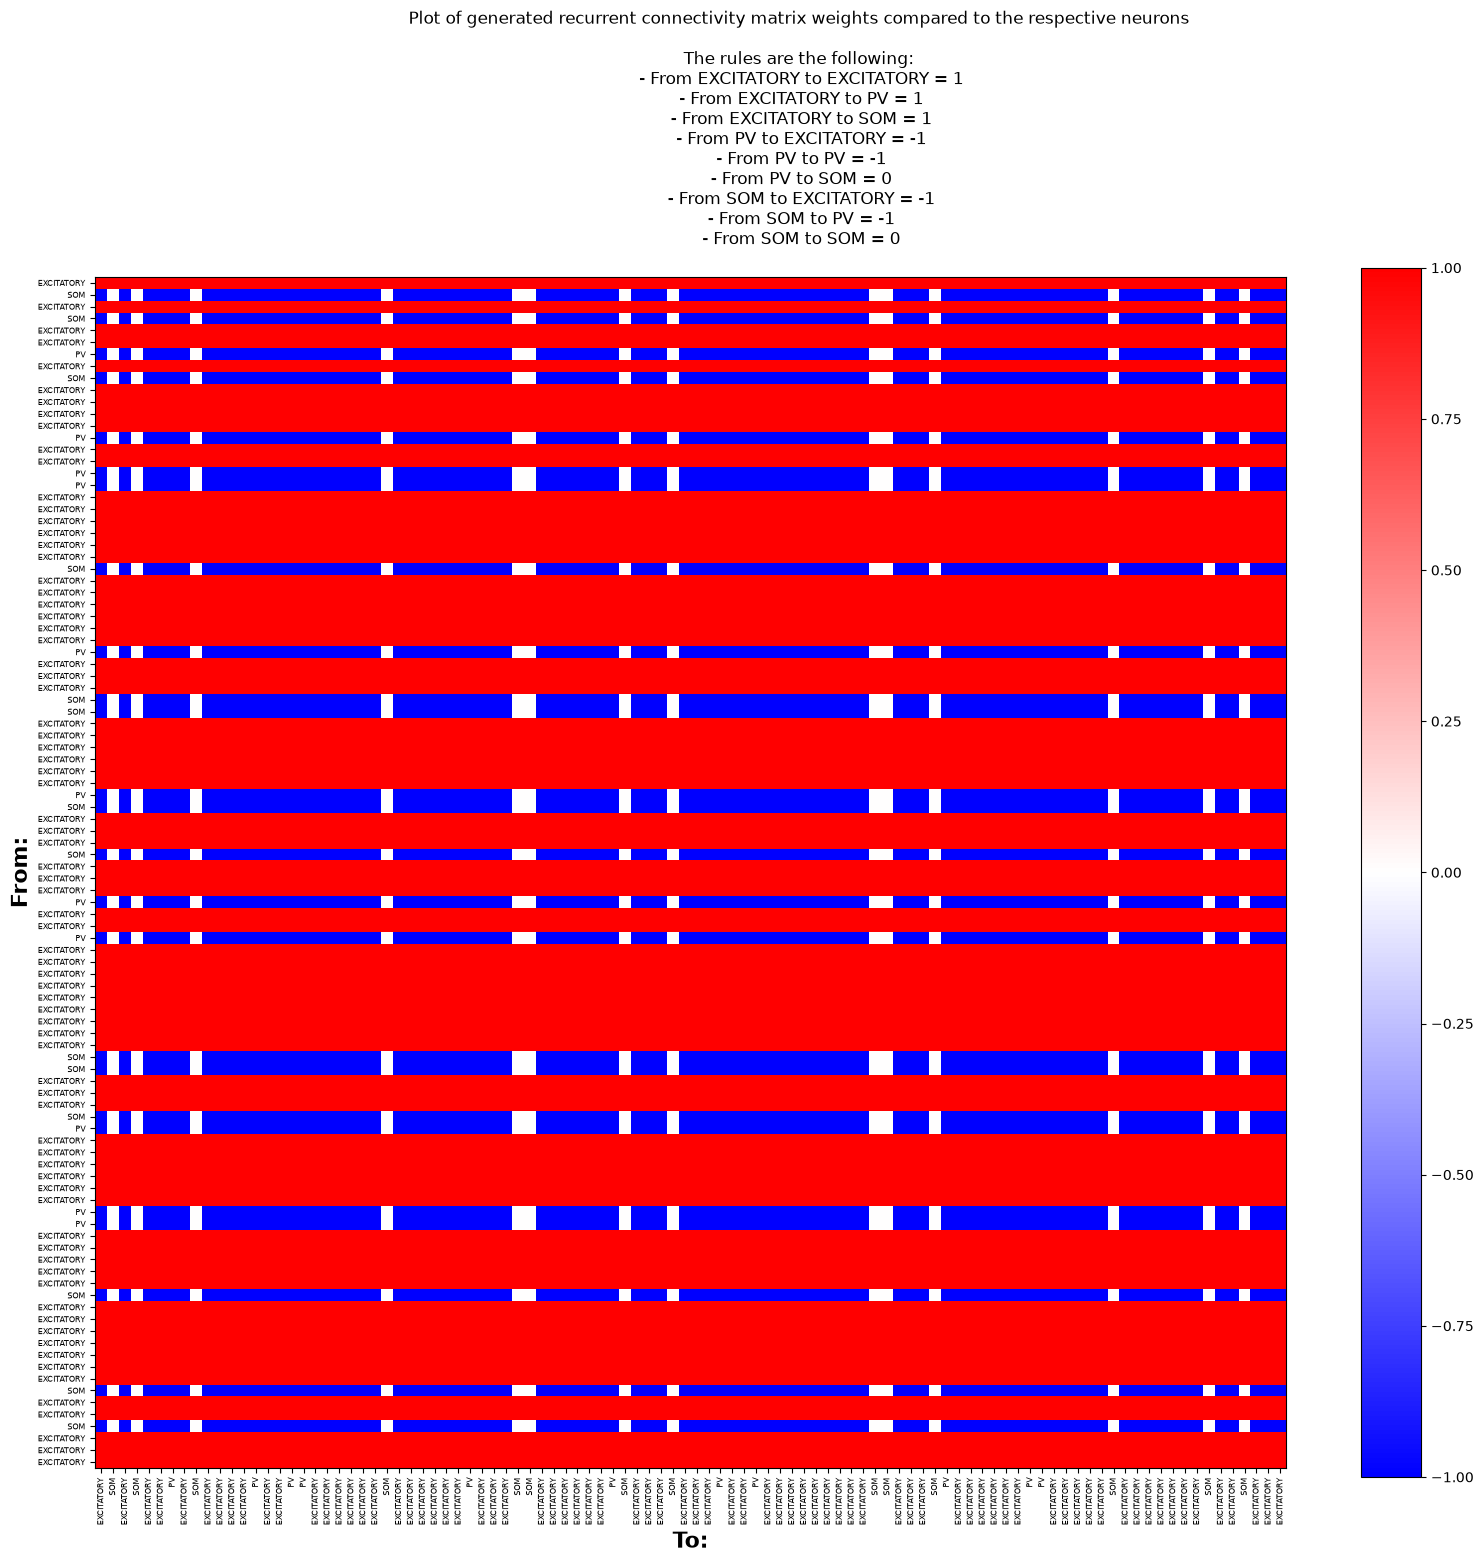

In [10]:
# This works!!

rec_matrices, pruned_matrices = connectivity.build_recurrent_and_pruned_matrices(neurons)
plot_rec_matrix(neurons, rec_matrices)

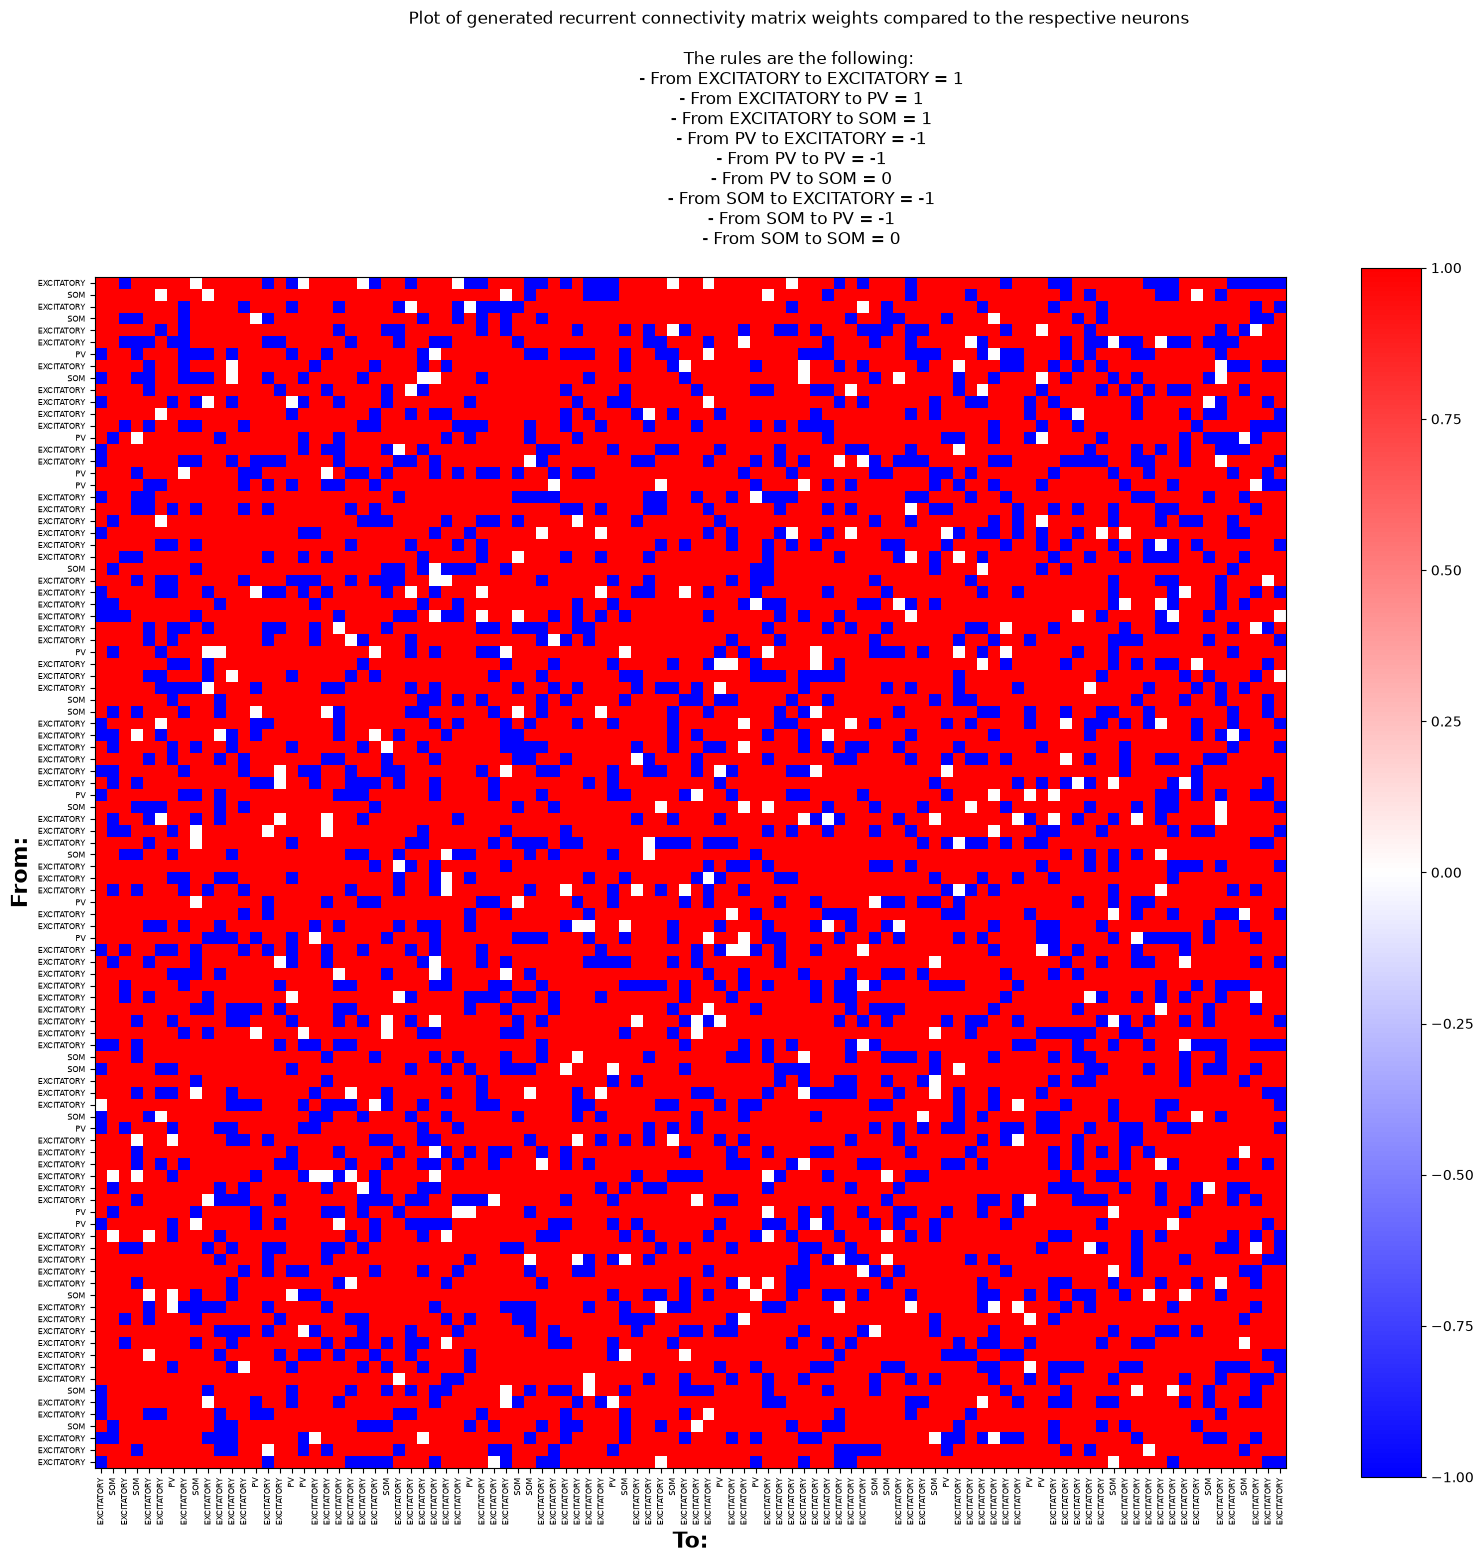

In [11]:
plot_rec_matrix(neurons, pruned_matrices)